In [1]:
import dynamiqs as dq
dq.set_device('cpu')
import jax
import jax.numpy as jnp
from jax import value_and_grad,grad, vmap,jit
from jax import make_jaxpr
import qcsys as qs
import jaxquantum as jqt
import matplotlib.pyplot as plt
from IPython.display import clear_output
from functools import partial
import math
from flax import struct

@struct.dataclass
class MyTransmon(qs.SingleChargeTransmon):
    '''
    The SingleChargeTransmon or Transmon in qcsys doesn't use the same hamiltonian as scqubit's
    I define this Transmon to keep it consistent with scqubit
    '''
    N_max_charge: int = struct.field(pytree_node=False)

    @classmethod
    def create(cls, N, N_max_charge, params, label=0, use_linear=False):
        return cls(N, N_max_charge, params, label, use_linear, N_max_charge)
    
    def get_H_full(self):
        #  consistant with scqubits 
        dimension = 2 * self.N_max_charge + 1
        def generate_hamiltonian_element(ind, Ec, N_max_charge, ng):
            return 4.0 * Ec * (ind - N_max_charge - ng) ** 2

        dim_range = jnp.arange(dimension)
        hamiltonian_mat = jnp.diag(vmap(generate_hamiltonian_element, in_axes=(0, None, None, None))(dim_range, self.params["Ec"], self.N_max_charge, self.params["ng"]))
        ind = jnp.arange(dimension - 1)
        hamiltonian_mat = hamiltonian_mat.at[ind, ind + 1].set(-self.params["Ej"] / 2.0)
        hamiltonian_mat = hamiltonian_mat.at[ind + 1, ind].set(-self.params["Ej"] / 2.0)
        hamiltonian_mat = jnp.array(hamiltonian_mat, dtype=jnp.complex128)
        H  = jqt.Qarray.create(hamiltonian_mat)
        # print(H.data)
        return  H
    def build_n_op(self):
        return jqt.Qarray.create(jnp.diag(jnp.arange(-self.N_max_charge, self.N_max_charge + 1)))
    @jit
    def get_op_in_H_eigenbasis(self, op):
        if type(op) == jqt.Qarray:
            op = op.data
        evecs = self.eig_systems["vecs"][:, : self.N]
        op = jnp.dot(jnp.conjugate(evecs.transpose()), jnp.dot(op, evecs))
        return jqt.Qarray.create(op)
    

# These are helper functions
def calculate_eig(Ns, H: jqt.Qarray):
    N_tot = math.prod(Ns)
    vals, kets = jnp.linalg.eigh(H.data)

    ketsT = kets.T

    def get_product_idx(edx):
        argmax = jnp.argmax(jnp.abs(ketsT[edx]))
        return  argmax  # product index
    edxs = jnp.arange(N_tot)
    product_indices_sorted_by_eval = vmap(get_product_idx)(edxs)
    return (vals,kets,product_indices_sorted_by_eval) # Here kets is equivalent to the S in qutip.Qobj.transform

def find_closest_dressed_index(product_index, product_indices_sorted_by_eval):
    dressed_index = jnp.argmin(jnp.abs(product_index - product_indices_sorted_by_eval))
    return dressed_index.item()

def transform_op_into_dressed_basis_jax(op_matrix: jqt.Qarray, 
                                        S: jax.Array) -> jax.Array:
    """
    Transform an operator into the dressed basis using JAX.

    Parameters:
    - op_matrix: A 2D JAX array representing the operator's matrix.
    - S: A 2D JAX array representing the dressed eigenvectors similar to the S in qutip.Qobj.transform

    Returns:
    - A 2D JAX array representing the transformed operator.
    """
    data = jnp.dot(S, jnp.dot(op_matrix.data, S.T.conj()))
    return data

def square_pulse_with_rise_fall(t,
                                args = {}):
    
    w_d = args['w_d']
    amp = args['amp']
    t_start = args.get('t_start', 0) 
    t_rise = args.get('t_rise', 0)
    t_square = args.get('t_square', 0)

    def cos_modulation():
        return 2 * jnp.pi * amp * jnp.cos(w_d * 2 * jnp.pi * t)
    
    t_fall_start = t_start + t_rise + t_square 
    t_end = t_fall_start + t_rise 

    before_pulse_start = jnp.less(t, t_start)
    during_rise_segment = jnp.logical_and(jnp.greater(t_rise, 0), jnp.logical_and(jnp.greater_equal(t, t_start), jnp.less_equal(t, t_start + t_rise)))
    constant_amplitude_segment = jnp.logical_and(jnp.greater(t, t_start + t_rise), jnp.less_equal(t, t_fall_start))
    during_fall_segment = jnp.logical_and(jnp.greater(t_rise, 0), jnp.logical_and(jnp.greater(t, t_fall_start), jnp.less_equal(t, t_end)))

    return jnp.where(before_pulse_start, 0,
                    jnp.where(during_rise_segment, jnp.sin(jnp.pi * (t - t_start) / (2 * t_rise)) ** 2 * cos_modulation(),
                            jnp.where(constant_amplitude_segment, cos_modulation(),
                                        jnp.where(during_fall_segment, jnp.sin(jnp.pi * (t_end - t) / (2 * t_rise)) ** 2 * cos_modulation(), 0))))


2024-03-28 16:42:46.718455: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:280] failed call to cuInit: UNKNOWN ERROR (100)


In [41]:
solver = dq.solver.Tsit5(
                    rtol= 1e-06,
                    atol= 1e-06,
                    safety_factor= 0.9,
                    min_factor= 0.2,
                    max_factor = 5.0,
                    max_steps = int(1e4*1000),
                )

n_lvls_fluxonium = 20
n_lvls_transmon = 4


Ej_f = 2.7
Ec_f = 0.6
El_f = 0.13
qsf = qs.Fluxonium.create(
    n_lvls_fluxonium,
    {"Ej": Ej_f, "Ec": Ec_f, "El": El_f, "phi_ext": 0.0},
    N_pre_diag=100,
    use_linear = False
    )

g_tf = 0.2
Ec_t = 0.2

t_rise = 30

truncated_dim = 80 # will include 7,1
def truncate(data: jnp.array):
    return data[:,:]

tot_dim = truncated_dim

pulse_length = 2.47029937e+02 
Ej_t = 3.40890048e+01
amp_with_2pi = 9.13069185e-03

t_tot = t_rise + pulse_length
tlist = jnp.linspace(0,t_tot,int(t_tot))

qst = MyTransmon.create(
    N = n_lvls_transmon,
    params = {"Ej": Ej_t, "Ec": Ec_t,"ng":0.0},
    N_max_charge=10
    )

devices = [qsf, qst]
f_indx = 0
t_indx = 1
Ns = [device.N for device in devices]
fn = qs.promote(qsf.ops["n"], f_indx, Ns)
tn = qs.promote(qst.ops['n'], t_indx, Ns)

g_tf = 0.2
system = qs.System.create(devices, couplings=[
    g_tf *  fn @ tn
    ])
system.params["g_tf"] = g_tf
system_evals_in_product_indices, system_evecs_in_product_indices = system.calculate_eig_linear()
system_evals_sorted, system_evecs_sorted, product_indices_sorted_by_eval = calculate_eig(Ns, system.get_H())
driven_op = transform_op_into_dressed_basis_jax(tn, system_evecs_sorted.T)

w_d = system_evals_in_product_indices[0,1] - system_evals_in_product_indices[0,0]
pulse_shape_args={
    'w_d': w_d,
    'amp': amp_with_2pi/(2*jnp.pi),
    't_rise': t_rise,
    't_square': pulse_length - t_rise
}      

def _H(t):
    _H =  2 * jnp.pi *truncate(jnp.diag(system_evals_sorted))
    _H += truncate(driven_op) * square_pulse_with_rise_fall(t, pulse_shape_args)
    return _H 
H =  dq.timecallable(_H)

psi0_list = [truncate(dq.basis(tot_dim,find_closest_dressed_index(l*qst.N, product_indices_sorted_by_eval)))
                    for l in [0,1,2]] #00,10,20

e_ops = []
for ql in range(8):
    for tl in range(4):
        e_ops.append(truncate(dq.basis_dm(math.prod(Ns),  find_closest_dressed_index(ql*qst.N+tl, product_indices_sorted_by_eval))))

result = dq.sesolve(
            H = H,
            psi0 = psi0_list,
            tsave = tlist,
            solver = solver,
            exp_ops = e_ops
            )

/home/kai/miniconda3/envs/test/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(-1e-05, 0.0001)

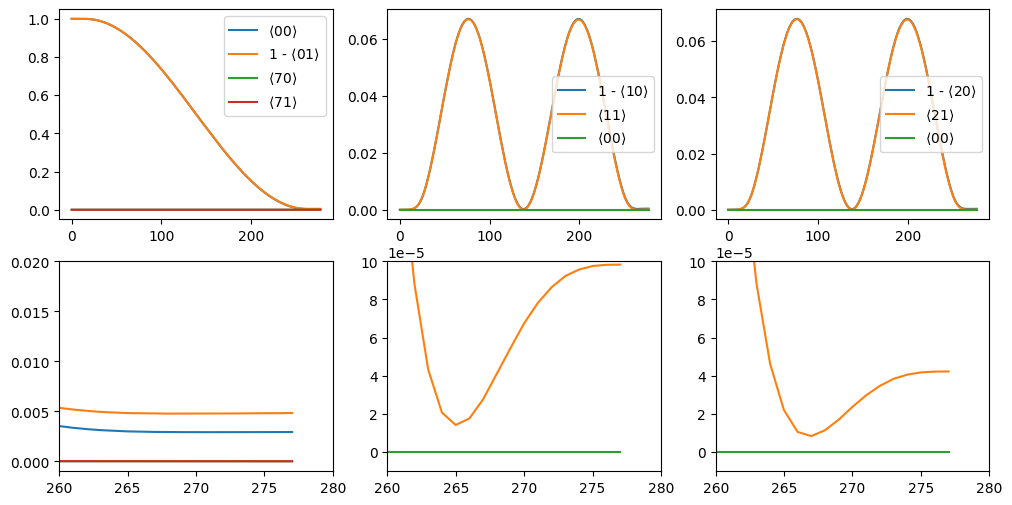

In [42]:
colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [
                        [(0,0),(0,1),(7,0),(7,1)],
                        [(1,0),(1,1),(0,0)],
                        [(2,0),(2,1),(0,0)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            if (ql,tl) not in [(0,1), (1,0),(2,0)]:
                axes[row, col].plot(tlist,result.expects[col][i],label = rf"$\langle{ql}{tl}\rangle$")
            else:
                axes[row, col].plot(tlist,1 - result.expects[col][i],label = rf"1 - $\langle{ql}{tl}\rangle$")
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    axes[1,col].set_xlim(260,280)

axes[1,0].set_ylim(-1e-3,2e-2)
axes[1,1].set_ylim(-1e-5,1e-4)
axes[1,2].set_ylim(-1e-5,1e-4)


In [46]:
dq.trace(dq.todm(result.states[0][-1]))

Array(0.99809624-1.03990459e-18j, dtype=complex128)